# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [7]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [8]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [9]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [10]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipykernel_56852/2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [11]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [12]:
model(Variable(xx))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

In [13]:
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):
    #inputs = Variable(x_train_bias)
    #target = Variable(y_train)
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred = model(inputs)

    #loss cálculo da função de perda
    loss = torch.mean((y_pred - target)**2)

    # backward propagation - cálculo gradient
    loss.backward()

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/100], loss: 0.022983
Epoch[40/100], loss: 0.021432
Epoch[60/100], loss: 0.021207
Epoch[80/100], loss: 0.021175
Epoch[100/100], loss: 0.021170


## Avaliação

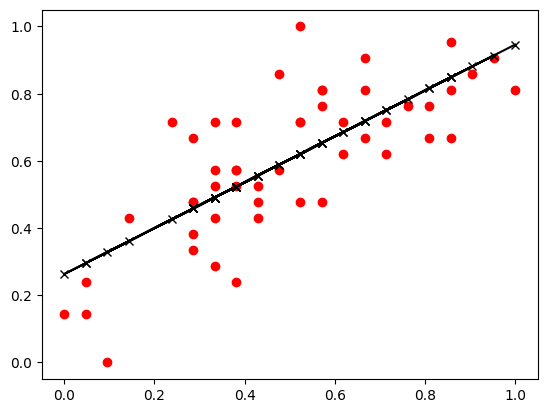

In [14]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Acessando os parâmetros

In [15]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

### Parâmetros ótimos, solução analítica

In [16]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data`? Por que precisa do `data`?
   

- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos
   parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.

## Ploting vectors

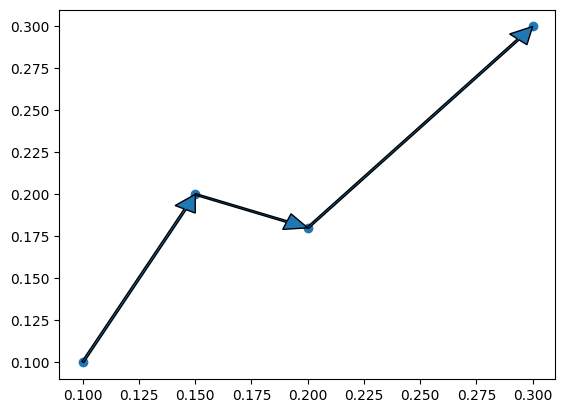

In [17]:
# Exemplo
w0_list = [0.1, 0.15, 0.2, 0.3]
w1_list = [0.1, 0.2, 0.18, 0.3]
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

# Aprendizados

---
## Exercício 1 — Por que usar `loss.data`?

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school

Em versões mais antigas do PyTorch, tensores eram divididos em `Variable` (com gradiente) e `Tensor` (sem). `loss.data` acessava o tensor subjacente **sem** o histórico do Autograd, permitindo imprimir ou salvar o valor escalar sem acumular memória do grafo computacional.

Nas versões modernas (>= 0.4), `Variable` foi depreciado e os tensores suportam `requires_grad` nativamente. Hoje usa-se `loss.item()` para extrair um float Python puro, que é semanticamente equivalente e mais idiomático.

**Resumo:** `.data` = tensor sem autograd; `.item()` = escalar Python — ambos evitam guardar o grafo computacional ao imprimir.


## Exercício 2 — MSE com pesos treinados


In [18]:
from torch.autograd import Variable
import torch

y_pred_ex2 = model(Variable(x_train_bias))
loss_ex2 = torch.mean((y_pred_ex2 - y_train) ** 2)
print(f'MSE com pesos treinados: {loss_ex2.item():.6f}')


MSE com pesos treinados: 0.021170


## Exercício 3 — Evolução dos Parâmetros + Solução Ótima


Pesos ótimos: w0=0.2613, w1=0.6865


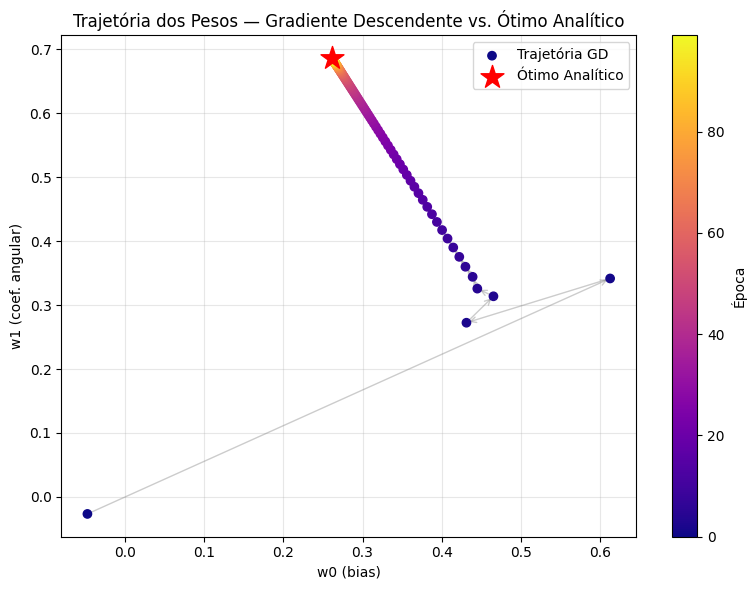

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

# Re-treinar do zero guardando w0 e w1
torch.manual_seed(1234)
iris = load_iris()
data = iris.data[iris.target==1,::2]
x_tr = data[:,0:1].astype(np.float32)
y_tr = data[:,1:2].astype(np.float32)
n_s = x_tr.shape[0]
x_tr -= x_tr.min(); x_tr /= x_tr.max()
y_tr -= y_tr.min(); y_tr /= y_tr.max()
x_bias = np.hstack([np.ones((n_s,1)), x_tr])
x_bias_t = torch.FloatTensor(x_bias)
y_t = torch.FloatTensor(y_tr)

model3 = torch.nn.Linear(2, 1, bias=False)
model3.weight.data = torch.zeros(1,2)
torch.nn.init.uniform_(model3.weight.data, -0.1, 0.1)

w0_list3, w1_list3 = [], []
lr3, epochs3 = 0.5, 100

for epoch in range(epochs3):
    w0_list3.append(model3.weight.data[0][0].item())
    w1_list3.append(model3.weight.data[0][1].item())
    y_pred3 = model3(x_bias_t)
    loss3 = torch.mean((y_pred3 - y_t)**2)
    loss3.backward()
    model3.weight.data -= lr3 * model3.weight.grad.data
    model3.weight.grad.data.zero_()

# Solução analítica
x_bt = x_bias_t
w_opt3 = (torch.inverse(x_bt.t().mm(x_bt)).mm(x_bt.t())).mm(y_t)
w0_opt, w1_opt = w_opt3[0].item(), w_opt3[1].item()
print(f'Pesos ótimos: w0={w0_opt:.4f}, w1={w1_opt:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(w0_list3, w1_list3, c=range(epochs3), cmap='plasma', zorder=5, label='Trajetória GD')
plt.colorbar(sc, ax=ax, label='Época')

w0_old3 = None
for (w0, w1) in zip(w0_list3, w1_list3):
    if w0_old3 is not None:
        ax.annotate('', xy=(w0, w1), xytext=(w0_old3, w1_old3),
                    arrowprops=dict(arrowstyle='->', color='gray', alpha=0.4))
    w0_old3, w1_old3 = w0, w1

ax.scatter([w0_opt], [w1_opt], marker='*', s=300, color='red', zorder=10, label='Ótimo Analítico')
ax.set_xlabel('w0 (bias)')
ax.set_ylabel('w1 (coef. angular)')
ax.set_title('Trajetória dos Pesos — Gradiente Descendente vs. Ótimo Analítico')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 📚 Aprendizados — Autograd e `loss.backward()`

### Como a Diferenciação Automática Substitui o Gradiente Manual

No notebook NumPy (2.2), calculávamos o gradiente explicitamente:
```python
w_grad = (2/M) * X^T (Xw^T - y)
```

No PyTorch com Autograd, a engine cuida disso automaticamente:

1. **Forward pass:** `y_pred = model(inputs)` — PyTorch constrói um **grafo computacional** que rastreia cada operação.
2. **Cálculo da loss:** `loss = torch.mean((y_pred - target)**2)` — a loss é um tensor que conhece sua 'história' de operações.
3. **`loss.backward()`:** aplica a **regra da cadeia** (chain rule) de forma automática e recursiva, percorrendo o grafo de trás para frente e acumulando os gradientes em `param.grad` para cada parâmetro.
4. **Atualização:** `model.weight.data -= lr * model.weight.grad.data` — usa o gradiente já calculado.
5. **`model.weight.grad.data.zero_()`:** limpa o gradiente antes da próxima iteração (gradientes se acumulam por padrão no PyTorch).

### Vantagem do Autograd
Qualquer função diferenciável pode ser usada como loss ou camada — sem precisar derivar manualmente. Isso torna o PyTorch extremamente flexível para arquiteturas complexas.
